In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import math

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch import nn
import torch.nn.functional as F

# Ensure project root on sys.path for local imports when running directly
try:
    HERE = os.path.dirname(os.path.abspath(__file__))  # type: ignore[name-defined]
except NameError:
    HERE = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(HERE, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
# Add notebooks directory to sys.path for local imports
NOTEBOOKS_DIR = os.path.join(HERE, "notebooks")
if NOTEBOOKS_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOKS_DIR)

from train_dist_encoder import train, save_encoder, load_encoder
from cls.vectorhash.assoc_utils_np_2D import gen_gbook_2d, path_integration_Wgg_2d, module_wise_NN_2d
from cls.utils.GridUtils import *

In [2]:
lambdas = [11,12,13]
Ng = np.sum(np.square(lambdas))
Npos = np.prod(lambdas)
# Npos = 300
gbook = gen_gbook_2d(lambdas, Ng, Npos)
Phi_np = smooth_gbook(gbook, lambdas, 0.25)
Phi = torch.tensor(Phi_np, dtype=torch.float32)

KeyboardInterrupt: 

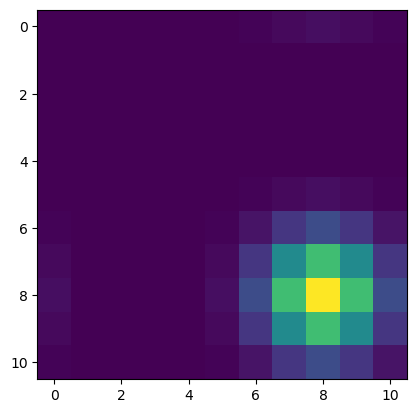

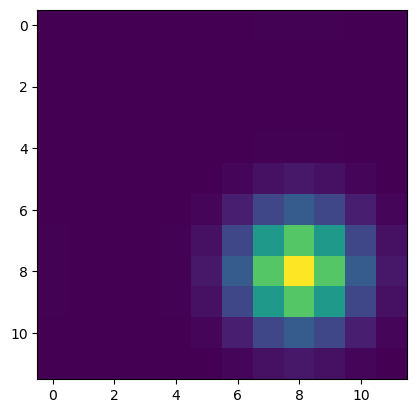

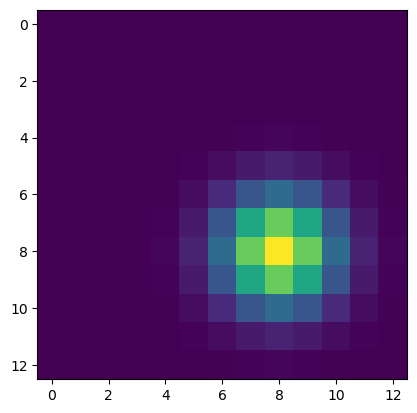

In [3]:
%matplotlib inline
i = 0
for l in lambdas:
    plt.imshow(Phi_np[i:i+l**2, 8, 8].reshape(l, l))
    i += l**2
    plt.show()

In [6]:
%matplotlib inline

config = {
    "model_params": {
        "lambdas": lambdas,
        "hidden_dim": 512,
        "hidden_channels": 128,
        "num_layers": 3,
        "out_dim": 128,
        "num_hidden_layers": 2,
        "kernel_size": 5,
        "nonlinearity": "gelu",
        "output_nonlinearity": "tanh",
        "gain": 5,
        "Npos": 50,
        "Nenv": 200
    },
    "training_params": {
        "lr": 0.0001,
        "batch_size": 8192,
        "epochs": 200,
        "gain_start": 1,
        "gain_end": 5,
        "gain_up_epochs": 50,
        "uniformity_lambda_start": 0,
        "uniformity_lambda_end": 0.1,
        "uniformity_lambda_scale_up_epochs": 25,
        "cka_alpha": 1,
        "cka_topk": 20,
        "mod_loss_lambda": 0.75,
    },
    "hopfield_params": {
        "alpha": 0.85
    }
}

encoder = train(Phi, config)

Run directory: /home/jackking/cls/encoders/run_20260401_170913
Sampled 200 non-overlapping 50x50 patches (took 308 attempts)
Precomputed 8800 curvature triples.
Using device: cuda | N=500000 | code_dim=434 | embed_dim=128
RBF tau (median dist) = 876.5843
Epoch 01 | train_align_loss=1.7233 | align_loss=0.9666 | local_loss=nan | Pearson(sim)=0.0164 | Spearman(sim)=0.0080 | TripletAcc=0.503 | NNconsistency=0.032
Saved encoder to /home/jackking/cls/encoders/run_20260401_170913/encoder_ep1.pt
Epoch 02 | train_align_loss=1.6887 | align_loss=0.9556 | local_loss=nan | Pearson(sim)=0.0097 | Spearman(sim)=0.0002 | TripletAcc=0.502 | NNconsistency=0.042
Saved encoder to /home/jackking/cls/encoders/run_20260401_170913/encoder_ep2.pt
Epoch 03 | train_align_loss=1.6708 | align_loss=0.9486 | local_loss=nan | Pearson(sim)=0.0124 | Spearman(sim)=0.0051 | TripletAcc=0.501 | NNconsistency=0.044
Saved encoder to /home/jackking/cls/encoders/run_20260401_170913/encoder_ep3.pt
Epoch 04 | train_align_loss=1.6

KeyboardInterrupt: 

In [7]:
# lower learning rate, larger model.
config = {
    "model_params": {
        "lambdas": lambdas,
        "hidden_dim": 512,
        "hidden_channels": 128,
        "num_layers": 3,
        "out_dim": 128,
        "num_hidden_layers": 2,
        "kernel_size": 5,
        "nonlinearity": "gelu",
        "output_nonlinearity": "tanh",
        "gain": 5,
        "Npos": 50,
        "Nenv": 200
    },
    "training_params": {
        "lr": 0.0001,
        "batch_size": 8192,
        "epochs": 200,
        "gain_start": 1,
        "gain_end": 5,
        "gain_up_epochs": 50,
        "uniformity_lambda_start": 0,
        "uniformity_lambda_end": 0.1,
        "uniformity_lambda_scale_up_epochs": 25,
        "cka_alpha": 1,
        "cka_topk": 20,
        "mod_loss_lambda": 0.75,
    },
    "hopfield_params": {
        "alpha": 0.85
    }
}

encoder = train(Phi, config)

In [359]:
encoder, config = load_encoder("goated_cnn_encoder.pt")

In [8]:
save_encoder(encoder, config, "lambda_11_12_13_full_wNpos=50.pt")

#"lambda_11_12_13_full_wNpos=200.pt" -- could be trained for longer.

In [361]:
gain = config["model_params"]["gain"]
embed_dim = config["model_params"]["out_dim"]

code_dim, H, W = Phi.shape
Phi_flat = Phi.reshape(code_dim, H*W).T.to(device)
batch_size = 1000  # adjust as needed according to GPU/CPU RAM constraints
encoded_Phi_chunks = []
with torch.no_grad():
    for i in range(0, Phi_flat.shape[0], batch_size):
        encoded_chunk = encoder(Phi_flat[i:i+batch_size], gain=gain).detach().cpu()
        encoded_Phi_chunks.append(encoded_chunk)
encoded_Phi = torch.cat(encoded_Phi_chunks, dim=0)
encoded_Phi_grid = encoded_Phi.reshape(Npos, Npos, embed_dim).to("cpu").numpy()

In [364]:
idx = 450
phix = encoded_Phi_grid[idx, idx, :]

#vectorized version
cosine_sims = np.sum(encoded_Phi_grid * phix, axis=-1) / np.sqrt(np.sum(encoded_Phi_grid**2, axis=-1) * np.sum(phix**2, axis=-1))

plt.imshow(cosine_sims)

plt.title(f"Cosine_sim(E(phi({idx},{idx})), E(phi(x,y))), lambdas = {lambdas}")
plt.xlabel("delta(x)")
plt.ylabel("delta(y)")
plt.colorbar(label="cosine sim")
ax = plt.gca()
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.yaxis.get_offset_text().set_visible(False)
plt.legend()
plt.savefig("cosine_sims_grid.eps")
plt.show()

plt.plot(cosine_sims[idx])
plt.title("Cosine_sim(E(phi(150,150)), E(phi(150, x))), lambdas = [11,12,13]")
plt.savefig("cosine_sims_plot.eps")
plt.show()

# Plot all cosine similarity matrices in a grid

idxs = np.arange(120, 180, 10)
num_plots = len(idxs)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))
axes = axes.flatten() if num_plots > 1 else [axes]

for ax_idx, idx in enumerate(idxs):
    phix = encoded_Phi_grid[idx, idx, :]
    phix_up = encoded_Phi_grid[idx-1, idx, :] - phix
    phix_down = encoded_Phi_grid[idx+1, idx, :] - phix
    phix_left = encoded_Phi_grid[idx, idx-1, :] - phix
    phix_right = encoded_Phi_grid[idx, idx+1, :] - phix

    directions = np.stack([phix_up, phix_down, phix_left, phix_right], axis=-1)
    norms = np.linalg.norm(directions, axis=0)
    cosine_sims = (directions.T @ directions) / np.outer(norms, norms)
    
    im = axes[ax_idx].imshow(cosine_sims, vmin=-1.0, vmax=1.0)
    axes[ax_idx].set_title(f"idx={idx}")
    plt.colorbar(im, ax=axes[ax_idx])
    axes[ax_idx].set_xticks(range(4))
    axes[ax_idx].set_yticks(range(4))
    axes[ax_idx].set_xticklabels(["up", "down", "left", "right"])
    axes[ax_idx].set_yticklabels(["up", "down", "left", "right"])

# Remove empty subplots if any
for ax in axes[num_plots:]:
    ax.axis('off')

plt.tight_layout()
plt.show()



In [155]:
# -----------------------------
# Core utilities
# -----------------------------
def build_direction_vectors_grid(encoded_Phi_grid: np.ndarray):
    """
    Build 4 directional displacement *grids* from a (H, W, D) grid.

    Returns:
        dir_grids: dict with keys {"up","down","left","right"}.
        Each value has shape (H-2, W-2, D), aligned on interior centers.

    convention:
        - "neighbor_to_center": v = center - neighbor  (incoming)
        - "center_to_neighbor": v = neighbor - center  (outgoing)
    """
    if encoded_Phi_grid.ndim != 3:
        raise ValueError(f"encoded_Phi_grid must have shape (H, W, D); got {encoded_Phi_grid.shape}")

    H, W, D = encoded_Phi_grid.shape
    if H < 3 or W < 3:
        raise ValueError("Need H,W >= 3 to form interior centers.")

    center = encoded_Phi_grid[1:-1, 1:-1, :]          # (H-2, W-2, D)
    up_n   = encoded_Phi_grid[:-2, 1:-1, :]
    down_n = encoded_Phi_grid[2:, 1:-1, :]
    left_n = encoded_Phi_grid[1:-1, :-2, :]
    right_n= encoded_Phi_grid[1:-1, 2:, :]

    up    = center - up_n
    down  = center - down_n
    left  = center - left_n
    right = center - right_n

    return {"up": up, "down": down, "left": left, "right": right}


def normalize_rows(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Row-wise L2 normalization to unit vectors."""
    norms = np.linalg.norm(X, axis=-1, keepdims=True)
    return X / (norms + eps)


def plot_sim_matrix(sim: np.ndarray, title: str, labels=None, vmin=-1, vmax=1):
    if labels is None:
        labels = ["up", "down", "left", "right"]
    plt.figure()
    plt.imshow(sim, vmin=vmin, vmax=vmax)
    plt.xticks(range(4), labels)
    plt.yticks(range(4), labels)
    plt.colorbar(label="mean cosine similarity")
    plt.title(title)
    plt.show()


# -----------------------------
# Method 1: Matched-center mean cosine (same centers)
# -----------------------------
def sim_matched_centers_from_grids(dir_grids_n: dict, n_sample=1000, seed=None, replace=False):
    """
    Sample the same interior centers (i,j) across directions and average cosine.
    dir_grids_n values are normalized and shaped (H-2, W-2, D).
    """
    keys = ["up", "down", "left", "right"]
    for k in keys:
        if k not in dir_grids_n:
            raise ValueError(f"Missing key {k} in dir_grids_n")

    Hc, Wc, D = dir_grids_n["up"].shape
    rng = np.random.default_rng(seed)
    M = Hc * Wc
    n = min(n_sample, M)

    if replace:
        flat_idx = rng.integers(0, M, size=n)
    else:
        flat_idx = rng.choice(M, size=n, replace=False)

    ii = flat_idx // Wc
    jj = flat_idx % Wc

    X = np.stack([dir_grids_n[k][ii, jj, :] for k in keys], axis=0)  # (4, n, D)
    sim = np.einsum("ind,jnd->ij", X, X) / n
    return sim


# -----------------------------
# Method 2: Global random independent pairs
# -----------------------------
def sim_global_random_pairs_from_grids(dir_grids_n: dict, n_pairs=20000, seed=None):
    """
    For each (i,j), sample independent random centers from each direction grid and average cosine.
    """
    keys = ["up", "down", "left", "right"]
    Hc, Wc, D = dir_grids_n["up"].shape
    M = Hc * Wc
    rng = np.random.default_rng(seed)

    # Flatten once for efficient indexing
    flat = {k: dir_grids_n[k].reshape(M, D) for k in keys}

    sim = np.zeros((4, 4), dtype=np.float64)
    for i, ki in enumerate(keys):
        A = flat[ki]
        ia = rng.integers(0, M, size=n_pairs)
        for j, kj in enumerate(keys):
            B = flat[kj]
            ib = rng.integers(0, M, size=n_pairs)
            sim[i, j] = np.mean(np.sum(A[ia] * B[ib], axis=-1))
    return sim


def sim_global_allpairs_square_explicit(dir_grids_n: dict, top: int, left: int, size: int):
    """
    Explicit check version: builds the full pairwise cosine matrix for each (i,j) over the square
    and averages it. Only use for small squares (size maybe <= ~150 depending on D).

    Returns: (4,4) sim matrix.
    """
    keys = ["up", "down", "left", "right"]
    Hc, Wc, D = dir_grids_n["up"].shape

    if size <= 0:
        raise ValueError("size must be positive.")
    if top < 0 or left < 0 or top + size > Hc or left + size > Wc:
        raise ValueError(f"Square out of bounds for interior grid {(Hc, Wc)}: "
                         f"top={top}, left={left}, size={size}")

    r0, r1 = top, top + size
    c0, c1 = left, left + size

    vecs = {}
    for k in keys:
        vecs[k] = dir_grids_n[k][r0:r1, c0:c1, :].reshape(-1, D)  # (n, D), n=size*size

    sim = np.zeros((4, 4), dtype=np.float64)
    for i, ki in enumerate(keys):
        A = vecs[ki]  # (n, D)
        for j, kj in enumerate(keys):
            B = vecs[kj]  # (n, D)
            C = A @ B.T   # (n, n) cosine matrix (rows normalized)
            sim[i, j] = C.mean()
    return sim


# -----------------------------
# Example: run all three methods
# -----------------------------
labels = ["up", "down", "left", "right"]

# Build displacement grids + normalize
dir_grids = build_direction_vectors_grid(encoded_Phi_grid)
dir_grids_n = {k: normalize_rows(v) for k, v in dir_grids.items()}

# Method 1: matched centers (same (i,j))
sim1 = sim_matched_centers_from_grids(dir_grids_n, n_sample=2000, seed=0, replace=False)
plot_sim_matrix(sim1, "Matched-center mean cosine (same centers)", labels=labels)

# Method 2: global random independent pairs
sim2 = sim_global_random_pairs_from_grids(dir_grids_n, n_pairs=50000, seed=0)
plot_sim_matrix(sim2, "Global mean cosine (independent random pairs)", labels=labels)

# Method 3: global all-pairs within a square region (fast exact)
size = 20 
top, left = 100, 100  
sim3 = sim_global_allpairs_square_explicit(dir_grids_n, top=top, left=left, size=size)
plot_sim_matrix(sim3, f"Global all-pairs mean cosine in square top={top}, left={left}, size={size}", labels=labels)


In [158]:
def parallel_transport_sphere(v, A, B, eps=1e-12):
    """
    Parallel transport v ∈ T_A S^n to T_B S^n along the shortest geodesic on the unit sphere.

    Inputs:
      v: (d,) tangent at A (i.e., v·A = 0)
      A: (d,) point on unit sphere
      B: (d,) point on unit sphere
    Returns:
      w: (d,) transported vector tangent at B (i.e., w·B = 0)

    Notes:
      - If A and B are (nearly) antipodal, shortest geodesic is not unique -> transport ambiguous.
      - If A == B, returns v (after re-projection to tangent space at A).
    """
    v = np.asarray(v, dtype=float)
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    # Normalize A, B to the unit sphere
    nA = np.linalg.norm(A)
    nB = np.linalg.norm(B)
    if nA < eps or nB < eps:
        raise ValueError("A and B must be nonzero vectors.")
    A = A / nA
    B = B / nB

    # Project v to tangent space at A (robustness)
    v = v - np.dot(v, A) * A

    c = float(np.dot(A, B))  # cos(theta)

    # A == B (or extremely close)
    if 1.0 - c < 1e-10:
        # Ensure tangent at B (same as A)
        return v - np.dot(v, B) * B

    # Antipodal (or extremely close): transport not unique
    if 1.0 + c < 1e-10:
        raise ValueError("A and B are (nearly) antipodal; shortest-geodesic parallel transport is not unique.")

    # Closed-form parallel transport along shortest geodesic
    # w = v - (v·B)/(1 + A·B) * (A + B)
    w = v - (np.dot(v, B) / (1.0 + c)) * (A + B)

    # Clean up numerical drift: enforce tangency at B
    w = w - np.dot(w, B) * B
    return w

def angle_between(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.arccos(np.clip(cos_theta, -1, 1))

def signed_angle_at_point(v1, v2, B):
    """Signed angle from v1 to v2 in tangent plane at B."""
    # This is the high-D analog of: sign = dot(B, cross(v1, v2))
    # We need the component of the "cross product" along B
    
    # Project onto orthonormal basis in tangent plane
    e1 = v1 / np.linalg.norm(v1)
    e2 = v2 - np.dot(v2, e1) * e1
    e2 = e2 / np.linalg.norm(e2)
    
    # Coordinates of v2 in this basis
    x = np.dot(v2, e1)
    y = np.dot(v2, e2)
    
    angle = np.arctan2(y, x)
    return angle

def to_2d(v, e1, e2):
    return np.array([np.dot(v, e1), np.dot(v, e2)])

# Signed angle in 2D
def signed_angle_2d(v1, v2):
    """Signed angle from v1 to v2 in 2D."""
    return np.arctan2(v1[0]*v2[1] - v1[1]*v2[0], v1[0]*v2[0] + v1[1]*v2[1])

Ax, Ay = 150, 150

orientations = np.zeros((300, 300))

for Bx in range(299):
    for By in range(299):
        A = encoded_Phi_grid[Ax, Ay, :]
        v_up = encoded_Phi_grid[Ax, Ay-1, :] - encoded_Phi_grid[Ax, Ay, :]
        v_right = encoded_Phi_grid[Ax+1, Ay, :] - encoded_Phi_grid[Ax, Ay, :]
        v_left = encoded_Phi_grid[Ax-1, Ay, :] - encoded_Phi_grid[Ax, Ay, :]
        B = encoded_Phi_grid[Bx, By, :]

        w_up = encoded_Phi_grid[Bx, By-1, :] - encoded_Phi_grid[Bx, By, :]
        w_right = encoded_Phi_grid[Bx+1, By, :] - encoded_Phi_grid[Bx, By, :]
        w_left = encoded_Phi_grid[Bx-1, By, :] - encoded_Phi_grid[Bx, By, :]

        w_up_trans = parallel_transport_sphere(v_up, A, B)
        w_right_trans = parallel_transport_sphere(v_right, A, B)
        w_left_trans = parallel_transport_sphere(v_left, A, B)
        
        # Build basis from transported vectors (which carry orientation from A)
        e1 = w_up_trans / np.linalg.norm(w_up_trans)
        temp = w_right_trans - np.dot(w_right_trans, e1) * e1
        e2 = temp / np.linalg.norm(temp)

        # Now check: is w_right on the same side of w_up as w_right_trans is of w_up_trans?
        signed_angle_actual = signed_angle_2d(to_2d(w_up, e1, e2), to_2d(w_right, e1, e2))
        # orientations[Bx, By] = signed_angle_actual
        sign = np.sign(signed_angle_actual)
        angle = np.abs(angle_between(w_up, w_right))
        orientations[Bx, By] = angle * sign

"""
We pick a reference point A where we know the orientation (w_right is counterclockwise from w_up, or whatever it is).
We parallel transport w_up and w_right from A to every other point B. These transported vectors carry A's orientation with them.
At B, we use the transported vectors to define a coordinate system. Then we check: in this coordinate system, is the actual w_right at B on the same side of the actual w_up as it was at A?
If yes everywhere, the encoding preserves orientation globally. If the sign flips somewhere, orientation is broken at that point.
"""

In [159]:
plt.imshow(orientations)
plt.title("Orientation")
plt.colorbar()
plt.show()

plt.imshow((orientations > 0))
print(np.sum((orientations > 0)) / (300 * 300))
plt.title("Orientation sign")
plt.colorbar()
plt.show()

plt.imshow((np.abs(orientations) > 1.2) & (np.abs(orientations) < 1.94))
print(np.sum((np.abs(orientations) > 1.2) & (np.abs(orientations) < 1.94)) / (300 * 300))
plt.title("Orientation > 1.2 and < 1.94")
plt.colorbar()
plt.show()

center = orientations[Ax-25:Ax+25, Ay-25:Ay+25]

plt.imshow(center)
plt.title("Orientation center")
plt.colorbar()
plt.show()

plt.imshow((center > 1.4) & (center < 1.74))
plt.title("Orientation center > 1.4 and < 1.74")
plt.colorbar()
plt.show()

In [162]:
# Assuming your grid is, say, 200x200
grid_size = 300
d = 32  # embedding dimension, or whatever you're using

# Synthetic encoding that PRESERVES orientation
def make_orientation_preserving_grid(grid_size, d, scale=0.01):
    grid = np.zeros((grid_size, grid_size, d))
    for x in range(grid_size):
        for y in range(grid_size):
            v = np.zeros(d)
            v[0] = (x - grid_size/2) * scale
            v[1] = (y - grid_size/2) * scale
            v[2] = 1.0
            grid[x, y, :] = v / np.linalg.norm(v)
    return grid

# Synthetic encoding that BREAKS orientation (reflection in one axis)
def make_orientation_breaking_grid(grid_size, d, scale=0.01):
    grid = np.zeros((grid_size, grid_size, d))
    for x in range(grid_size):
        for y in range(grid_size):
            # Rotation angle that varies with position
            theta = (x / grid_size) * np.pi * 2  # 0 to pi across grid
            
            x_centered = (x - grid_size/2) * scale
            y_centered = (y - grid_size/2) * scale
            
            # Rotate by theta
            v = np.zeros(d)
            v[0] = x_centered * np.cos(theta) - y_centered * np.sin(theta)
            v[1] = x_centered * np.sin(theta) + y_centered * np.cos(theta)
            v[2] = 1.0
            grid[x, y, :] = v / np.linalg.norm(v)
    return grid

# Test both
# print("=== ORIENTATION PRESERVING ===")
# test_grid = make_orientation_preserving_grid(grid_size, d)
# Run your test code with encoded_Phi_grid = test_grid

# print("\n=== ORIENTATION BREAKING (reflection) ===")
test_grid = make_orientation_breaking_grid(grid_size, d)
# # Run your test code with encoded_Phi_grid = test_grid_broken

In [200]:
def compute_projection_matrix(d_forward, d_right):
    e1 = d_forward / np.linalg.norm(d_forward)
    e2 = d_right - np.dot(d_right, e1) * e1
    e2 = e2 / np.linalg.norm(e2)
    W = np.stack([e2, e1], axis=0)  # shape (2, n)
    return W

def project_query(W, d_query):
	return W @ d_query  # shape (2,)

def classify_direction(q):
    """
    q: 2D vector [x, y]
    Returns: 0=forward, 1=right, 2=backward, 3=left
    """
    angle = np.arctan2(q[1], q[0])  # range: -pi to pi
    
    if -np.pi/4 <= angle < np.pi/4:
        return 1  # right
    elif np.pi/4 <= angle < 3*np.pi/4:
        return 0  # forward
    elif -3*np.pi/4 <= angle < -np.pi/4:
        return 2  # backward
    else:
        return 3  # left

Ax = 50
Ay = 50
A = encoded_Phi_grid[Ax, Ay, :]
d_forward = encoded_Phi_grid[Ax, Ay-1, :] - encoded_Phi_grid[Ax, Ay, :]
d_right = encoded_Phi_grid[Ax+1, Ay, :] - encoded_Phi_grid[Ax, Ay, :]
d_left = encoded_Phi_grid[Ax-1, Ay, :] - encoded_Phi_grid[Ax, Ay, :]
d_backward = encoded_Phi_grid[Ax, Ay+1, :] - encoded_Phi_grid[Ax, Ay, :]
W = compute_projection_matrix(d_forward, d_right)

print("forward", classify_direction(project_query(W, d_forward)))
print("right", classify_direction(project_query(W, d_right)))
print("backward", classify_direction(project_query(W, d_backward)))
print("left", classify_direction(project_query(W, d_left)))

forwards = np.zeros((299, 299))
rights = np.zeros((299, 299))
lefts = np.zeros((299, 299))
backwards = np.zeros((299, 299))

for Bx in range(299):
    for By in range(299):
        d_forward = encoded_Phi_grid[Bx, By-1, :] - encoded_Phi_grid[Bx, By, :]
        d_right = encoded_Phi_grid[Bx+1, By, :] - encoded_Phi_grid[Bx, By, :]
        d_left = encoded_Phi_grid[Bx-1, By, :] - encoded_Phi_grid[Bx, By, :]
        d_backward = encoded_Phi_grid[Bx, By+1, :] - encoded_Phi_grid[Bx, By, :]

        W = compute_projection_matrix(d_forward, d_right)
        forwards[Bx, By] = classify_direction(project_query(W, d_forward))
        rights[Bx, By] = classify_direction(project_query(W, d_right))
        lefts[Bx, By] = classify_direction(project_query(W, d_left))
        backwards[Bx, By] = classify_direction(project_query(W, d_backward))
 
#[Ax-25:Ax+25, Ay-25:Ay+25]

plt.imshow(forwards)
plt.title("Forwards")   
plt.colorbar()
print(np.sum(forwards == 0) / (300*300))
plt.show()

plt.imshow(rights)
plt.title("Rights")
plt.colorbar()
print(np.sum(rights == 1) / (300*300))
plt.show()

plt.imshow(lefts)
plt.title("Lefts")
plt.colorbar()
print(np.sum(lefts == 3) / (300*300))
plt.show()

plt.imshow(backwards)
plt.title("Backwards")
plt.colorbar()
print(np.sum(backwards == 2) / (300*300))
plt.show()

In [197]:
#this works perfectly at absolute locality, 
# but in terms of generalizing to other points it's the same as the 2d version.

def classify_direction_3d(q, f, r, b, l):
    """
    q: 3D query vector
    f, r, b, l: 3D reference vectors for forward, right, backward, left
    Returns: 0=forward, 1=right, 2=backward, 3=left
    """
    dots = [
        np.dot(q, f) / (np.linalg.norm(q) * np.linalg.norm(f)),
        np.dot(q, r) / (np.linalg.norm(q) * np.linalg.norm(r)),
        np.dot(q, b) / (np.linalg.norm(q) * np.linalg.norm(b)),
        np.dot(q, l) / (np.linalg.norm(q) * np.linalg.norm(l)),
    ]
    return np.argmax(dots)

Ax = 50
Ay = 50
A = encoded_Phi_grid[Ax, Ay, :]
d_forward_A = encoded_Phi_grid[Ax, Ay-1, :] - encoded_Phi_grid[Ax, Ay, :]
d_right_A = encoded_Phi_grid[Ax+1, Ay, :] - encoded_Phi_grid[Ax, Ay, :]
d_left_A = encoded_Phi_grid[Ax-1, Ay, :] - encoded_Phi_grid[Ax, Ay, :]
d_backward_A = encoded_Phi_grid[Ax, Ay+1, :] - encoded_Phi_grid[Ax, Ay, :]

forwards = np.zeros((299, 299))
rights = np.zeros((299, 299))
lefts = np.zeros((299, 299))
backwards = np.zeros((299, 299))

for Bx in range(299):
    for By in range(299):
        d_forward = encoded_Phi_grid[Bx, By-1, :] - encoded_Phi_grid[Bx, By, :]
        d_right = encoded_Phi_grid[Bx+1, By, :] - encoded_Phi_grid[Bx, By, :]
        d_left = encoded_Phi_grid[Bx-1, By, :] - encoded_Phi_grid[Bx, By, :]
        d_backward = encoded_Phi_grid[Bx, By+1, :] - encoded_Phi_grid[Bx, By, :]

        forwards[Bx, By] = classify_direction_3d(d_forward, d_forward_A, d_right_A, d_backward_A, d_left_A)
        rights[Bx, By] = classify_direction_3d(d_right, d_forward_A, d_right_A, d_backward_A, d_left_A)
        lefts[Bx, By] = classify_direction_3d(d_left, d_forward_A, d_right_A, d_backward_A, d_left_A)
        backwards[Bx, By] = classify_direction_3d(d_backward, d_forward_A, d_right_A, d_backward_A, d_left_A)
 
#[Ax-25:Ax+25, Ay-25:Ay+25]

plt.imshow(forwards[Ax-25:Ax+25, Ay-25:Ay+25])
plt.title("Forwards")   
plt.colorbar()
print(np.sum(forwards == 0) / (300*300))
plt.show()

plt.imshow(rights[Ax-25:Ax+25, Ay-25:Ay+25])
plt.title("Rights")
plt.colorbar()
print(np.sum(rights == 1) / (300*300))
plt.show()

plt.imshow(lefts[Ax-25:Ax+25, Ay-25:Ay+25])
plt.title("Lefts")
plt.colorbar()
print(np.sum(lefts == 3) / (300*300))
plt.show()

plt.imshow(backwards[Ax-25:Ax+25, Ay-25:Ay+25])
plt.title("Backwards")
plt.colorbar()
print(np.sum(backwards == 2) / (300*300))
plt.show()

In [ ]:
A = encoded_Phi_grid[Ax, Ay, :]
d_forward = encoded_Phi_grid[Ax, Ay-1, :] - encoded_Phi_grid[Ax, Ay, :]
d_right = encoded_Phi_grid[Ax+1, Ay, :] - encoded_Phi_grid[Ax, Ay, :]
d_left = encoded_Phi_grid[Ax-1, Ay, :] - encoded_Phi_grid[Ax, Ay, :]
W = compute_projection_matrix(d_forward, d_right)
q = project_query(W, d_right)
classify_direction(q)

In [89]:
# Flatten grid to (n_points, embed_dim)
pca = PCA(n_components=2)
pcs = pca.fit_transform(encoded_Phi)  # (n_points, 2)
pcs_grid = pcs.reshape(encoded_Phi_grid.shape[0], encoded_Phi_grid.shape[1], 2)

plt.figure(figsize=(6,6))
plt.scatter(pcs[:,0], pcs[:,1])
plt.show()

plt.figure()
plt.imshow(pcs_grid[...,0], cmap='coolwarm')
plt.colorbar(label="PC1")
plt.title("PCA Component 1 across grid")
plt.show()

plt.figure()
plt.imshow(pcs_grid[...,1], cmap='coolwarm')
plt.colorbar(label="PC2")
plt.title("PCA Component 2 across grid")
plt.show()

In [98]:
start = 200
size = 100
encoded_Phi_grid_copy = encoded_Phi_grid[start:start+size, start:start+size, :]

delta_up_ephi = encoded_Phi_grid_copy[:-1, :, :] - encoded_Phi_grid_copy[1:, :, :]
delta_down_ephi = encoded_Phi_grid_copy[1:, :, :] - encoded_Phi_grid_copy[:-1, :, :]
delta_left_ephi = encoded_Phi_grid_copy[:, :-1, :] - encoded_Phi_grid_copy[:, 1:, :]
delta_right_ephi = encoded_Phi_grid_copy[:, 1:, :] - encoded_Phi_grid_copy[:, :-1, :]
delta_up_ephi = delta_up_ephi.reshape(-1, embed_dim)
delta_down_ephi = delta_down_ephi.reshape(-1, embed_dim)
delta_left_ephi = delta_left_ephi.reshape(-1, embed_dim)
delta_right_ephi = delta_right_ephi.reshape(-1, embed_dim)
X = np.concatenate([delta_up_ephi, delta_down_ephi, delta_left_ephi, delta_right_ephi], axis=0)
direction_labels = ["up", "down", "left", "right"]
Y = np.repeat(direction_labels, len(delta_up_ephi))

# Flatten grid to (n_points, embed_dim)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)  # (n_points, 2)

plt.figure()
for direction in ["up", "down", "left", "right"]:
    mask = (Y == direction)
    plt.scatter(pcs[mask, 0], pcs[mask, 1], s=5, label=direction)
plt.legend()
plt.title("PCA of deltas by direction")
plt.show()

# Plot just the centers of mass for each direction
plt.figure()
centers = []
for direction in ["up", "down", "left", "right"]:
    mask = (Y == direction)
    center = pcs[mask].mean(axis=0)
    centers.append(center)
    plt.scatter(center[0], center[1], s=100, label=direction)
for i, center in enumerate(centers):
    plt.text(center[0], center[1], direction_labels[i], fontsize=12, ha='center', va='center')
plt.legend()
plt.title("Centers of Mass in PCA space per direction")
plt.show()



In [ ]:
## need to make sure that with alpha = 1, it still does this fuck shit.
    ## maybe kind of? trying with uni = 0.01 to see what happens.
        ## okay yeah uni really fucks it

        ## try 1024

In [ ]:



# encoders_dir = "/home/jackking/cls/encoders"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # ========== FILTER SETTINGS ==========
# # Set to filter by a specific parameter. Set filter_value to None to show all.
# # Options: "cka_alpha", "gain", "uniformity"
# filter_by = "cka_alpha"  # which parameter to filter by
# filter_value = 5     # value to match (set to None to show all)
# # =====================================

# # Get all encoder files
# encoder_files = sorted([f for f in os.listdir(encoders_dir) if f.endswith('.pt') and f.startswith('encoder_')])

# # Pre-filter based on parameter
# filtered_files = []
# for encoder_file in encoder_files:
#     checkpoint = torch.load(os.path.join(encoders_dir, encoder_file), map_location=device, weights_only=False)
#     sweep_params = checkpoint.get("sweep_params", {})
#     config = checkpoint.get("config", {})
    
#     cka_alpha = sweep_params.get("cka_alpha")
#     gain = sweep_params.get("sigmoid_scale_end", config.get("gain", 1.0))
#     uniformity = sweep_params.get("uniformity_lambda_end")
    
#     if filter_value is None:
#         filtered_files.append((encoder_file, checkpoint))
#     elif filter_by == "cka_alpha" and cka_alpha == filter_value:
#         filtered_files.append((encoder_file, checkpoint))
#     elif filter_by == "gain" and gain == filter_value:
#         filtered_files.append((encoder_file, checkpoint))
#     elif filter_by == "uniformity" and uniformity == filter_value:
#         filtered_files.append((encoder_file, checkpoint))

# n_encoders = len(filtered_files)
# if n_encoders == 0:
#     print(f"No encoders found with {filter_by}={filter_value}")
# else:
#     n_cols = min(5, n_encoders)
#     n_rows = (n_encoders + n_cols - 1) // n_cols

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
#     axes = axes.flatten()

#     for idx, (encoder_file, checkpoint) in enumerate(filtered_files):
#         ax = axes[idx]
        
#         encoder, cfg = load_encoder(encoder_file)
        
#         # Get parameters
#         gain = cfg["gain"]
#         cka_alpha = cfg["cka_alpha"]
#         uni_lambda = cfg["uniformity"]
#         embed_dim = cfg["out_dim"]
        
#         # Encode
#         with torch.no_grad():
#             encoded_Phi = encoder(Phi_flat, gain=gain).detach()
#         encoded_Phi_grid = encoded_Phi.reshape(H, H, embed_dim).cpu().numpy()
        
#         # Compute cosine similarities
#         phix = encoded_Phi_grid[0, 0, :]
#         cosine_sims = []
#         for i in range(H):
#             phi_deltax = encoded_Phi_grid[i, 0, :]
#             sim = np.sum(phix * phi_deltax) / np.sqrt(np.sum(phix**2) * np.sum(phi_deltax**2))
#             cosine_sims.append(sim)
#         cosine_sims = np.array(cosine_sims)
        
#         # Find max past first 10 points
#         max_idx = 10 + np.argmax(cosine_sims[10:])
#         max_val = cosine_sims[max_idx]
        
#         # Plot
#         ax.plot(cosine_sims[:20])

#         ax.set_title(f"α={cka_alpha}, gain={gain}, uni={uni_lambda}\nmax={max_val:.3f}@{max_idx}\n{encoder_file}", fontsize=9)
#         ax.set_xlabel("Δx", fontsize=8)
#         ax.set_ylabel("cosine sim", fontsize=8)
#         ax.tick_params(labelsize=7)

#     # Hide empty subplots
#     for idx in range(n_encoders, len(axes)):
#         axes[idx].axis('off')

#     plt.suptitle(f"Filter: {filter_by}={filter_value}" if filter_value else "All encoders", fontsize=12)
#     plt.tight_layout()
#     plt.show()

In [25]:
plt.hist(encoded_Phi[0].detach().cpu().numpy())

In [79]:
n_envs = 2
size = 15

used = []  # store placed (x, y)
C_pairs = []
max_tries = 10_000  # guard against infinite loops
touch_ok = False      # set False to forbid touching
tries = 0
while len(C_pairs) < n_envs and tries < max_tries:
    x = np.random.randint(0, Npos - size + 1)
    y = np.random.randint(0, Npos - size + 1)
    if all(not overlaps(x, y, px, py, size, touch_ok) for (px, py) in used):
        used.append((x, y))
        C_pairs.append((x, y))
    tries += 1

all_env_indices = []
goal_states = []
goal_locations = []

for env_idx in range(n_envs):
    C_X, C_Y = C_pairs[env_idx]
    x, y = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
    env_indices = np.stack((C_X + x, C_Y + y), axis=-1)
    all_env_indices.append(env_indices)

    flat_env = env_indices.reshape(-1, 2)
    goal_loc = flat_env[np.random.choice(len(flat_env))]
    goal_states.append(Phi[:, goal_loc[0], goal_loc[1]])
    goal_locations.append(goal_loc)

width, height = Npos, Npos

for env_idx in range(n_envs):
    env_indices = all_env_indices[env_idx]
    pos = env_indices.reshape(-1, 2)
    plt.scatter(pos[:, 0], pos[:, 1], label=f"env {env_idx}")

plt.xlim(0, width)
plt.ylim(0, height)
plt.gca().set_aspect('equal', adjustable='box')  # keep the aspect ratio square
plt.legend()
plt.show()

In [80]:
class HopfieldEncoderRetriever(torch.nn.Module):
    """
    Hopfield-style retrieval on top of a learned unit-sphere encoder F.
    Now supports sequential adds via .add(...).
    """
    def __init__(self, encoder: torch.nn.Module):
        super().__init__()
        self.encoder = encoder
        self.register_buffer("Z_mem", None)   # [N, d] unit embeddings
        self.register_buffer("V_mem", None)   # [N, P] values
        self.N = 0
        self.embed_dim = None
        self.value_dim = None

    @torch.no_grad()
    def index(self,
              Phi_mem: torch.Tensor,                # [N, code_dim]
              values: Optional[torch.Tensor] = None,# [N, P] (defaults to Phi_mem)
              batch_size: int = 4096) -> None:
        """Build memory bank from scratch."""
        device = next(self.encoder.parameters()).device
        Phi_mem = Phi_mem.to(device)
        V_mem = Phi_mem if values is None else values.to(device)

        Z_mem = self.encoder(Phi_mem, gain=gain)
        assert Z_mem.size(0) == V_mem.size(0), "values must align with memories"

        self.Z_mem = Z_mem
        self.V_mem = V_mem
        self.N = Z_mem.size(0)
        self.embed_dim = Z_mem.size(1)
        self.value_dim = V_mem.size(1) if V_mem.ndim == 2 else 1

    @torch.no_grad()
    def add(self,
            Phi_new: torch.Tensor,                 # [M, code_dim]
            values_new: Optional[torch.Tensor] = None,  # [M, P] (defaults to Phi_new)
            batch_size: int = 4096) -> None:
        """Append new memories (sequential storage)."""
        assert self.Z_mem is not None, "Call .index(...) before .add(...)"
        device = self.Z_mem.device
        Phi_new = Phi_new.to(device)
        V_new = Phi_new if values_new is None else values_new.to(device)

        Z_new = self.encoder(Phi_new, gain=gains[-1])
        assert Z_new.size(0) == V_new.size(0), "values must align with new memories"
        assert Z_new.size(1) == self.embed_dim, "embed dim mismatch with existing bank"
        if V_new.ndim == 1:
            V_new = V_new.unsqueeze(1)
        if self.V_mem.ndim == 1:
            self.V_mem = self.V_mem.unsqueeze(1)
        assert V_new.size(1) == self.V_mem.size(1), "value dim mismatch with existing bank"

        # append
        self.Z_mem = torch.cat([self.Z_mem, Z_new], dim=0)
        self.V_mem = torch.cat([self.V_mem, V_new], dim=0)
        self.N = self.Z_mem.size(0)

    @torch.no_grad()
    def clear(self) -> None:
        """Remove all memories."""
        self.Z_mem = None
        self.V_mem = None
        self.N = 0
        self.embed_dim = None
        self.value_dim = None

    @torch.no_grad()
    def reindex_all(self,
                    Phi_all: torch.Tensor,
                    values_all: Optional[torch.Tensor] = None,
                    batch_size: int = 4096) -> None:
        """Rebuild entire bank (use after changing encoder weights)."""
        self.index(Phi_all, values_all, batch_size=batch_size)

    @torch.no_grad()
    def retrieve(self,
                 Phi_q: torch.Tensor,               # [B, code_dim] or [code_dim]
                 mode: str = "hard",                # "hard" | "soft"
                 beta: float = 20.0,
                 k: int = 1,
                 return_attention: bool = True
                 ):
        assert self.Z_mem is not None and self.N > 0, "Memory bank is empty; call index/add."
        device = self.Z_mem.device

        if Phi_q.dim() == 1:
            Phi_q = Phi_q.unsqueeze(0)
        zq = self.encoder(Phi_q.to(device), gain=gain)          # [B, d]

        sim = zq @ self.Z_mem.T                      # [B, N]

        if mode == "soft":
            attn = (beta * sim).softmax(dim=-1)      # [B, N]
            out = attn @ self.V_mem                  # [B, P]
            return (out.squeeze(0) if out.size(0) == 1 else out,
                    (attn.squeeze(0) if return_attention and attn.size(0) == 1 else (attn if return_attention else None)),
                    None)

        elif mode == "hard":
            k = max(1, k)
            val, idx = torch.topk(sim, k=k, dim=-1, largest=True, sorted=True)  # [B, k]
            if k == 1:
                out = self.V_mem[idx.squeeze(-1)]     # [B, P]
                return (out.squeeze(0) if out.size(0) == 1 else out,
                        None,
                        idx.squeeze(-1).squeeze(0) if idx.size(0) == 1 else idx.squeeze(-1))
            else:
                out = self.V_mem[idx]                 # [B, k, P]
                return out, None, idx
        else:
            raise ValueError("mode must be 'hard' or 'soft'")

    @torch.no_grad()
    def nearest_indices(self, Phi_q: torch.Tensor, k: int = 1) -> torch.Tensor:
        """Return top-k indices by cosine."""
        if Phi_q.dim() == 1:
            Phi_q = Phi_q.unsqueeze(0)
        zq = self.encoder(Phi_q.to(self.Z_mem.device))
        sim = zq @ self.Z_mem.T
        _, idx = torch.topk(sim, k=k, dim=-1, largest=True, sorted=True)
        return idx.squeeze(0) if idx.size(0) == 1 else idx


In [81]:
Phi_mem = torch.stack(goal_states)

retriever = HopfieldEncoderRetriever(encoder).to(device)
retriever.index(Phi_mem=Phi_mem, values=torch.tensor(goal_locations, dtype=torch.float32))  # values defaults to Phi_mem

In [82]:
for env_idx in range(n_envs):
    correct = 0
    env_indices = all_env_indices[env_idx]
    for x in range(size):
        for y in range(size):
            location = env_indices[x, y]
            phi_query = Phi[:, location[0], location[1]]
            pos, attn, __ = retriever.retrieve(phi_query, mode="soft", beta=10000.0)
            # print(attn)
            # print("---")
            if torch.argmax(attn) == env_idx:
                correct += 1
    print(f"Env {env_idx} accuracy: {correct / (size * size)}")

In [83]:
class PIHopfield(nn.Module):
    """
    Minimal pseudoinverse Hopfield with optional memory cache for indexing.
      - fit(Z): builds W = Z^T @ pinv(Z^T); optionally caches Z (and values)
      - retrieve(q): x <- normalize(x @ W) for 'iters' steps
      - If Z is cached, retrieve can also return argmax cosine index (and optional value)

    Shapes:
      Z : [P, D]  (P memories, D-dim each)  -- rows are memories (already encoded)
      W : [D, D]
      q : [D] or [B, D]
      values (optional): [P, V] (e.g., positions)
    """
    def __init__(self, rcond: float = 1e-6):
        super().__init__()
        self.register_buffer("W", None)        # [D, D]
        self.register_buffer("Z_mem", None)    # [P, D] (optional cache for indexing)
        self.register_buffer("V_mem", None)    # [P, V] (optional attached values)
        self.rcond = rcond

    @torch.no_grad()
    def fit(self,
            Z: torch.Tensor,
            normalize: bool = True,
            store_memories: bool = True,
            values: Optional[torch.Tensor] = None):
        """
        Build W from memories Z (rows). Optionally cache Z (and values) for indexing.
        """
        assert Z.ndim == 2, "Z must be [P, D]"
        Zb = F.normalize(Z, dim=-1) if normalize else Z
        Zt = Zb.T                                               # [D, P]
        self.W = Zt @ torch.linalg.pinv(Zt, rcond=self.rcond)   # [D, D]

        if store_memories:
            self.Z_mem = Zb                                     # [P, D]
            if values is not None:
                assert values.shape[0] == Zb.shape[0], "values must align with Z rows"
                self.V_mem = values
            else:
                self.V_mem = None
        else:
            self.Z_mem = None
            self.V_mem = None

    @torch.no_grad()
    def retrieve(self,
                 q: torch.Tensor,
                 iters: int = 5,
                 normalize_each_step: bool = True,
                 return_index: bool = True,
                 topk: int = 1,
                 return_value: bool = False):
        """
        Iterative retrieval:
          x_{t+1} = normalize(x_t @ W)
        Returns:
          x*:   [B, D] (or [D] if input was 1D)
          idx:  [B] or [B, topk] (if Z_mem cached and return_index=True)
          vals: [B, V] or [B, topk, V] (if return_value=True and V_mem exists)
        """
        assert self.W is not None, "Call fit(Z) first."

        batched = (q.ndim == 2)
        x = q if batched else q.unsqueeze(0)                    # [B, D]

        for _ in range(max(1, iters)):
            x = x @ self.W
            if normalize_each_step:
                x = F.normalize(x, dim=-1)

        idx = vals = None
        if return_index:
            assert self.Z_mem is not None, "No cached memories; call fit(..., store_memories=True)."
            # cosine since rows of Z_mem are unit (if you normalized in fit)
            sims = x @ self.Z_mem.T                             # [B, P]
            if topk == 1:
                idx = sims.argmax(dim=-1)                       # [B]
                if return_value and (self.V_mem is not None):
                    vals = self.V_mem[idx]                      # [B, V]
            else:
                topk = max(1, int(topk))
                v, i = torch.topk(sims, k=topk, dim=-1, largest=True, sorted=True)  # i: [B, topk]
                idx = i
                if return_value and (self.V_mem is not None):
                    vals = self.V_mem[idx]                      # [B, topk, V]

        return (x if batched else x.squeeze(0),
                (idx if batched or idx is None else idx.squeeze(0)),
                (vals if (batched or vals is None) else vals.squeeze(0)))

    @torch.no_grad()
    def project_once(self, q: torch.Tensor):
        """Single projection step: x -> x @ W (no normalization)."""
        assert self.W is not None, "Call fit(Z) first."
        x = q if q.ndim == 2 else q.unsqueeze(0)
        x = x @ self.W
        return x if q.ndim == 2 else x.squeeze(0)

    @torch.no_grad()
    def nearest_indices(self, q: torch.Tensor, k: int = 1) -> torch.Tensor:
        """Direct cosine top-k using cached Z (no dynamics)."""
        assert self.Z_mem is not None, "No cached memories; call fit(..., store_memories=True)."
        x = q if q.ndim == 2 else q.unsqueeze(0)
        x = F.normalize(x, dim=-1)                # ensure fair cosine if caller didn't
        sims = x @ self.Z_mem.T
        _, idx = torch.topk(sims, k=k, dim=-1, largest=True, sorted=True)
        return idx if x.ndim == 2 else idx.squeeze(0)


def nearest_xy_cosine(q: torch.Tensor, M: torch.Tensor):
    """
    q : [D]
    M : [D, H, W]

    Returns:
      (y, x) indices of M[..., y, x] closest to q by cosine similarity.
    """
    # flatten grid: [D, H, W] -> [H*W, D]
    D, H, W = M.shape
    M = M.reshape(D, -1).T   # [H*W, D]

    # normalize
    # q_norm = F.normalize(q.unsqueeze(0), dim=-1)     # [1, D]
    # M_norm = F.normalize(M_flat, dim=-1)             # [H*W, D]

    # cosine similarity
    sim = (q @ M.T).squeeze(0)             # [H*W]
    idx = torch.argmax(sim).item()

    # convert flat index -> (y, x)
    y = idx // W
    x = idx % W
    return (y, x)

In [84]:
def hebbian_weights(Z, zero_diag=True, scale=None):
    """
    Z: [P, D] stored patterns (rows). We'll L2-normalize rows.
    Returns W: [D, D]
    """
    Z = F.normalize(Z, dim=-1)
    P, D = Z.shape
    W = Z.t() @ Z                       # sum z z^T
    if scale is None:
        scale = 1.0 / D                 # keeps gains reasonable
    W = scale * W
    if zero_diag:
        W.fill_diagonal_(0.0)
    return W

def hopfield_recall(
    x0,
    W,
    target=None,
    Phi_matrix=None,
    steps=15,
    beta=2.0,
    normalize_each=False,
    tanh=False,
    alpha=1,
    asynchronous=False,
    update_order="random",  # "random" | "sequential"
    rng=None,
):
    """
    x_{t+1} = tanh(beta * (W x_t)) (synchronous) or coordinate-updates (asynchronous).
    x0: [D]
    W : [D, D]
    Returns:
        x: final state
        cos_sims: list of cosine similarities to target at each step
        closest_idxs_2d: list of (i, j) indices into Phi_matrix at each step (if Phi_matrix is provided)
    """
    x = x0.clone()
    cos_sims = []
    closest_idxs_2d = []
    D = x.numel()

    for _ in range(steps):
        # record similarity to target (if provided)
        cos_sim = F.cosine_similarity(x, target, dim=0).item()
        cos_sims.append(cos_sim)
        if Phi_matrix is not None:
            sims_to_Phi = torch.tensordot(x, Phi_matrix, dims=([0], [0]))  # [H, W]
            flat_idx = torch.argmax(sims_to_Phi).item()
            i = flat_idx // Phi_matrix.shape[2]
            j = flat_idx % Phi_matrix.shape[2]
            closest_idxs_2d.append((i, j))

        if not asynchronous:
            delta_x = torch.tanh(beta * (W @ x)) if tanh else (W @ x)
            x = (1 - alpha) * x + alpha * delta_x
        else:
            # Asynchronous coordinate updates in-place, using latest partial state
            if update_order == "random":
                if rng is not None:
                    order = torch.randperm(D, generator=rng, device=x.device)
                else:
                    order = torch.randperm(D, device=x.device)
            else:
                order = torch.arange(D, device=x.device)

            # Maintain local field h = W @ x and update it incrementally for efficiency
            h = W @ x
            for k in order.tolist():
                hk = h[k]
                new_val = torch.tanh(beta * hk) if tanh else hk
                updated = (1 - alpha) * x[k] + alpha * new_val
                delta = updated - x[k]
                if delta != 0:
                    x[k] = updated
                    # h <- h + delta * W[:, k]
                    h = h + delta * W[:, k]

        if normalize_each:
            x = F.normalize(x, dim=0)

    # Add final similarity and closest index after last update
    cos_sim = F.cosine_similarity(x, target, dim=0).item()
    cos_sims.append(cos_sim)
    if Phi_matrix is not None:
        sims_to_Phi = torch.tensordot(x, Phi_matrix, dims=([0], [0]))  # [H, W]
        flat_idx = torch.argmax(sims_to_Phi).item()
        i = flat_idx // Phi_matrix.shape[2]
        j = flat_idx % Phi_matrix.shape[2]
        closest_idxs_2d.append((i, j))
        return x, cos_sims, closest_idxs_2d
    else:
        return x, cos_sims

def cosine(a, B):
    """a: [D], B: [P, D] -> [P]"""
    if B.ndim == 1:
        B = B.unsqueeze(0)
    return F.cosine_similarity(a.unsqueeze(0), B, dim=-1)

In [87]:
encoded_Phi = encoder(Phi_flat, gain=gain).detach().cpu()
encoded_Phi = encoded_Phi.T.reshape(embed_dim, H, H)

Phi_mem = torch.stack(goal_states).to(device)
Phi_mem_encoded = encoder(Phi_mem, gain=gain).detach().cpu()

# hop = PIHopfield()
# hop.fit(Phi_mem_encoded, normalize=False, values=torch.tensor(goal_locations, dtype=torch.float32))
# x_star, idx, pos = hop.retrieve(phi_query, iters=20)

W = hebbian_weights(Phi_mem_encoded, zero_diag=True, scale=None)

In [88]:
Phi_mem.shape

In [89]:
#make sim matrix for encoded_Phi
Phi_sims = encoded_Phi.view(embed_dim, -1).T@encoded_Phi.view(embed_dim, -1)
# plt.imshow(Phi_sims)
#count how many 1s in Phi_sims
print(torch.sum(Phi_sims == 1))
print((Phi_sims.shape[0]-torch.sum(Phi_sims == 1)) / Phi_sims.numel())

In [90]:
from matplotlib.lines import Line2D

for env_idx in range(n_envs):
    correct = 0
    env_indices = all_env_indices[env_idx]
    print(goal_locations[env_idx])

    y_lo, y_hi = env_indices[0, 0][0] - 3, env_indices[-1, 0][0] + 1
    x_lo, x_hi = env_indices[0, 0][1] - 1, env_indices[0, -1][1] + 1

    grid_inches = min(size * 2.0, 36)
    fig, axes = plt.subplots(
        size,
        size,
        figsize=(grid_inches, grid_inches),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    for x in range(size):
        for y in range(size):
            if x % 2 == 0 or y % 2 == 0:
                continue #for efficiency while testing
            location = env_indices[x, y]
            input = Phi[:, location[0], location[1]].unsqueeze(0).to(device)
            phi_query = encoder(
                input,
                gain=gain,
            ).detach().cpu()[0]

            Phi_sims = encoded_Phi.T @ phi_query
            flat_idx = torch.argmax(Phi_sims)
            i = flat_idx % H
            j = flat_idx // H

            sims_to_Phi = torch.tensordot(phi_query, encoded_Phi, dims=([0], [0]))
            flat_idx = torch.argmax(sims_to_Phi).item()
            i = flat_idx // encoded_Phi.shape[2]
            j = flat_idx % encoded_Phi.shape[2]

            x_star, cos_sims, closest_idxs_2d = hopfield_recall(
                phi_query,
                W,
                target=Phi_mem_encoded[env_idx],
                Phi_matrix=encoded_Phi,
                steps=20,
                beta=gain,
                normalize_each=True,
                tanh=True,
                alpha=0.85,
            )

            last_idx = closest_idxs_2d[-1]
            sims_to_Phi = torch.tensordot(x_star, encoded_Phi, dims=([0], [0])) / (
                torch.norm(x_star) * torch.norm(encoded_Phi, dim=0)
            )
            flat_idx = torch.argmax(sims_to_Phi).item()
            i = flat_idx // encoded_Phi.shape[2]
            j = flat_idx % encoded_Phi.shape[2]

            closest_idxs_2d_np = (
                torch.stack(closest_idxs_2d).cpu().numpy()
                if isinstance(closest_idxs_2d[0], torch.Tensor)
                else np.array(closest_idxs_2d)
            )
            print(closest_idxs_2d_np)

            ax = axes[x, y]
            ax.clear()
            ax.plot(closest_idxs_2d_np[:, 1], closest_idxs_2d_np[:, 0], marker="o", linewidth=1, markersize=1.5)
            ax.scatter(closest_idxs_2d_np[0, 1], closest_idxs_2d_np[0, 0], color="green", s=20, alpha=0.7)
            ax.scatter(closest_idxs_2d_np[-1, 1], closest_idxs_2d_np[-1, 0], color="red", s=20, alpha=0.7)
            ax.scatter(goal_locations[env_idx][1], goal_locations[env_idx][0], color="orange", s=20, alpha=0.7)
            ax.set_xlim(x_lo, x_hi)
            ax.set_ylim(y_lo, y_hi)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect("equal")
            ax.set_title(f"({x}, {y})", fontsize=8)

            if last_idx == tuple(goal_locations[env_idx]):
                correct += 1

    legend_handles = [
        Line2D([0], [0], color="C0", marker="o", label="trajectory"),
        Line2D([0], [0], marker="o", color="green", linestyle="None", label="start"),
        Line2D([0], [0], marker="o", color="red", linestyle="None", label="stop"),
        Line2D([0], [0], marker="o", color="orange", linestyle="None", label="goal"),
    ]
    legend_labels = ["trajectory", "start", "stop", "goal"]

    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 1.02),
    )

    print(f"Env {env_idx} accuracy: {correct / (size * size)}")

In [ ]:

    print(f"Env {env_idx} accuracy: {correct / (size * size)}")

In [184]:
for env_idx in range(n_envs):
    correct = 0
    env_indices = all_env_indices[env_idx]
    print(goal_locations[env_idx])

    y_lo, y_hi = env_indices[0, 0][0] - 3, env_indices[-1, 0][0] + 1
    x_lo, x_hi = env_indices[0, 0][1] - 1, env_indices[0, -1][1] + 1

    grid_inches = min(size * 2.0, 36)
    fig, axes = plt.subplots(
        size,
        size,
        figsize=(grid_inches, grid_inches),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    for x in range(size):
        for y in range(size):
            if x % 2 == 0 or y % 2 == 0:
                continue #for efficiency while testing
            location = env_indices[x, y]
            input = Phi[:, location[0], location[1]].unsqueeze(0).to(device)
            phi_query = encoder(
                input,
                gain=gain,
            ).detach().cpu()[0]

            Phi_sims = encoded_Phi.T @ phi_query
            flat_idx = torch.argmax(Phi_sims)
            i = flat_idx % H
            j = flat_idx // H

            sims_to_Phi = torch.tensordot(phi_query, encoded_Phi, dims=([0], [0]))
            flat_idx = torch.argmax(sims_to_Phi).item()
            i = flat_idx // encoded_Phi.shape[2]
            j = flat_idx % encoded_Phi.shape[2]

            x_star, cos_sims, closest_idxs_2d = hopfield_recall(
                phi_query,
                W,
                target=Phi_mem_encoded[env_idx],
                Phi_matrix=encoded_Phi,
                steps=20,
                beta=gain,
                normalize_each=True,
                tanh=True,
                alpha=0.85,
            )

            last_idx = closest_idxs_2d[-1]
            sims_to_Phi = torch.tensordot(x_star, encoded_Phi, dims=([0], [0])) / (
                torch.norm(x_star) * torch.norm(encoded_Phi, dim=0)
            )
            flat_idx = torch.argmax(sims_to_Phi).item()
            i = flat_idx // encoded_Phi.shape[2]
            j = flat_idx % encoded_Phi.shape[2]

            closest_idxs_2d_np = (
                torch.stack(closest_idxs_2d).cpu().numpy()
                if isinstance(closest_idxs_2d[0], torch.Tensor)
                else np.array(closest_idxs_2d)
            )
            print(closest_idxs_2d_np)

            ax = axes[x, y]
            ax.clear()
            ax.plot(closest_idxs_2d_np[:, 1], closest_idxs_2d_np[:, 0], marker="o", linewidth=1, markersize=1.5)
            ax.scatter(closest_idxs_2d_np[0, 1], closest_idxs_2d_np[0, 0], color="green", s=20, alpha=0.7)
            ax.scatter(closest_idxs_2d_np[-1, 1], closest_idxs_2d_np[-1, 0], color="red", s=20, alpha=0.7)
            ax.scatter(goal_locations[env_idx][1], goal_locations[env_idx][0], color="orange", s=20, alpha=0.7)
            ax.set_xlim(x_lo, x_hi)
            ax.set_ylim(y_lo, y_hi)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect("equal")
            ax.set_title(f"({x}, {y})", fontsize=8)

            if last_idx == tuple(goal_locations[env_idx]):
                correct += 1

    legend_handles = [
        Line2D([0], [0], color="C0", marker="o", label="trajectory"),
        Line2D([0], [0], marker="o", color="green", linestyle="None", label="start"),
        Line2D([0], [0], marker="o", color="red", linestyle="None", label="stop"),
        Line2D([0], [0], marker="o", color="orange", linestyle="None", label="goal"),
    ]
    legend_labels = ["trajectory", "start", "stop", "goal"]

    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 1.02),
    )

    print(f"Env {env_idx} accuracy: {correct / (size * size)}")

In [ ]:
for env_idx in range(n_envs):
    correct = 0
    env_indices = all_env_indices[env_idx]
    print(goal_locations[env_idx])
    for x in range(size):
        for y in range(size):
            location = env_indices[x, y]
            # print(location)
            # print(location)
            phi_query = encoder(Phi[:, location[0], location[1]].to(device), gain=gain).detach().cpu()
            # phi_query = encoded_Phi[:, location[0], location[1]]
            Phi_sims = encoded_Phi.T@phi_query
            flat_idx = torch.argmax(Phi_sims)
            i = flat_idx % H
            j = flat_idx // H
            # print(i,j)
            # print(torch.sort(Phi_sims.flatten())[0][-10:])
            sims_to_Phi = torch.tensordot(phi_query, encoded_Phi, dims=([0], [0]))
            # print(sims_to_Phi[location[0], location[1]])
            # print(sims_to_Phi[goal_locations[env_idx][0], goal_locations[env_idx][1]])

            flat_idx = torch.argmax(sims_to_Phi).item()
            i = flat_idx // encoded_Phi.shape[2]
            j = flat_idx % encoded_Phi.shape[2]
            # print(i, j)
            
            x_star, cos_sims, closest_idxs_2d = hopfield_recall(phi_query, W, target=Phi_mem_encoded[env_idx], Phi_matrix=encoded_Phi,
                                                steps=20, beta=gain, normalize_each=True, tanh=True, alpha=0.9) #0.00235)

            last_idx = closest_idxs_2d[-1]
            # print(phi_query@Phi_mem_encoded.T / torch.norm(phi_query) / torch.norm(Phi_mem_encoded, dim=1))
            # print(x_star@Phi_mem_encoded.T / torch.norm(x_star) / torch.norm(Phi_mem_encoded, dim=1))
            sims_to_Phi = torch.tensordot(x_star, encoded_Phi, dims=([0], [0])) / (torch.norm(x_star) * torch.norm(encoded_Phi, dim=0))
            # print(sims_to_Phi[location[0], location[1]])
            # print(sims_to_Phi[goal_locations[env_idx][0], goal_locations[env_idx][1]])

            flat_idx = torch.argmax(sims_to_Phi).item()
            i = flat_idx // encoded_Phi.shape[2]
            j = flat_idx % encoded_Phi.shape[2]
            print(i, j)

            print(cos_sims)
            print(closest_idxs_2d)
            plt.plot(cos_sims)
            plt.show()
            # Plot the trajectory of closest_idxs_2d
            closest_idxs_2d_np = torch.stack(closest_idxs_2d).cpu().numpy() if isinstance(closest_idxs_2d[0], torch.Tensor) else np.array(closest_idxs_2d)
            plt.figure()
            # Plot full trajectory in default color
            plt.plot(closest_idxs_2d_np[:,1], closest_idxs_2d_np[:,0], marker='o')
            # Color the first point green
            plt.scatter(closest_idxs_2d_np[0,1], closest_idxs_2d_np[0,0], color='green', s=100, label='start', alpha=0.5)
            # Color and label the last point as stop
            plt.scatter(closest_idxs_2d_np[-1,1], closest_idxs_2d_np[-1,0], color='red', s=100, label='stop', alpha=0.75)
            # Plot the goal location
            plt.scatter(goal_locations[env_idx][1], goal_locations[env_idx][0], color='orange', s=100, label='goal', alpha=0.5)
            plt.legend()
            plt.title("Trajectory (y vs x indices)")
            plt.xlabel("x")
            plt.ylabel("y")
            plt.ylim(env_indices[0,0][0]-5, env_indices[-1,0][0]+5)
            plt.xlim(env_indices[0,0][1]-5, env_indices[0,-1][1]+5)
            
            plt.show()

            # print(idx)
            # print("---")
            if last_idx == tuple(goal_locations[env_idx]):
                correct += 1

    print(f"Env {env_idx} accuracy: {correct / (size * size)}")

In [467]:
# hopfield_tanh_minimal.py
import torch
import torch.nn.functional as F

def hebbian_weights(Z, zero_diag=True, scale=None):
    """
    Z: [P, D] stored patterns (rows). We'll L2-normalize rows.
    Returns W: [D, D]
    """
    Z = F.normalize(Z, dim=-1)
    P, D = Z.shape
    W = Z.t() @ Z                       # sum z z^T
    if scale is None:
        scale = 1.0 / D                 # keeps gains reasonable
    W = scale * W
    if zero_diag:
        W.fill_diagonal_(0.0)
    return W

def hopfield_recall(x0, W, steps=15, beta=2.0, normalize_each=False):
    """
    x_{t+1} = tanh(beta * (W x_t))
    x0: [D]
    W : [D, D]
    """
    x = x0.clone()
    for _ in range(steps):
        x = torch.tanh(beta * (W @ x))
        if normalize_each:
            x = F.normalize(x, dim=0)
    return x

def cosine(a, B):
    """a: [D], B: [P, D] -> [P]"""
    if B.ndim == 1:
        B = B.unsqueeze(0)
    return F.cosine_similarity(a.unsqueeze(0), B, dim=-1)

if __name__ == "__main__":
    torch.manual_seed(0)

    # ---- setup ----
    P, D = 8, 128           # P patterns, D dims
    steps = 25
    beta  = 100
    noise_std = 0.35

    # 1) make continuous patterns (unit-norm)
    Z = torch.tanh(torch.randn(P, D)*beta)
    Z = F.normalize(Z, dim=-1)

    # 2) build Hebbian weights
    W = hebbian_weights(Z, zero_diag=True, scale=1/P)

    # 3) pick a pattern, corrupt, recall
    i_true = 3
    x0 = Z[i_true] + noise_std * torch.randn(D)
    # x0 = F.normalize(x0, dim=0)

    x_rec = hopfield_recall(x0, W, steps=steps, beta=beta, normalize_each=False)

    # 4) evaluate
    sims0 = cosine(x0, Z)
    simsR = cosine(x_rec, Z)
    i_hat = int(torch.argmax(simsR))

    print(x_rec)
    print(f"True idx: {i_true} | Recalled idx: {i_hat}")
    print(f"Cosine to true (before -> after): {sims0[i_true]:.3f} -> {simsR[i_true]:.3f}")
    print(f"Best-after cosine: {simsR.max().item():.3f}")
 